**Task 1: Problem Identification**

In [55]:
# Unzipping the uploaded dataset file

import zipfile

# Path of uploaded zip file

zip_path = '/content/part_2_cnn_computer_vision-20260514T175602Z-3-001.zip'

# Extracting dataset

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall('/content/dataset')

print("Dataset extracted successfully")

Dataset extracted successfully


In [56]:
# Checking dataset folders

import os

dataset_path = '/content/dataset'

os.listdir(dataset_path)

['part_2_cnn_computer_vision']

In [57]:
# Checking image class folders

image_folder = '/content/dataset/images'

os.listdir('/content/dataset/part_2_cnn_computer_vision/images')

['.DS_Store', 'normal', 'stain', 'dent', 'scratch']

**Observation:**

The dataset contains four main image categories: stain, normal, scratch, and dent. These folders represent different classes of surface conditions and defects.

The dataset also contains a .DS_Store file, which is a system-generated file and not part of the actual dataset classes. This file can be ignored during preprocessing and model training.

**Why the selected problem type is appropriate for the dataset.**

Image classification is the most appropriate problem type for this dataset because each image belongs to one predefined category such as normal, dent, scratch, or stain. The objective of the model is to analyze the visual patterns present in an image and predict the correct class label.

In this dataset, the model does not need to detect object locations or segment image regions. Instead, it only needs to identify which category the entire image belongs to. Therefore, image classification is the correct computer vision approach for solving this problem.

CNN models are highly suitable for image classification tasks because they can automatically learn important visual features such as edges, textures, scratches, stains, and defect patterns directly from image data.

**Task 2: Dataset Exploration**

In [58]:
# Importing required libraries for image exploration

import os
import cv2
import matplotlib.pyplot as plt

In [59]:
# Defining image dataset path

image_folder = '/content/dataset/part_2_cnn_computer_vision/images'

In [60]:
# Getting class names from dataset folders

classes = [folder for folder in os.listdir('/content/dataset/part_2_cnn_computer_vision/images') if folder != '.DS_Store']

# Printing class names

print("Classes:", classes)

# Printing total number of classes

print("Total Number of Classes:", len(classes))

Classes: ['normal', 'stain', 'dent', 'scratch']
Total Number of Classes: 4


In [61]:
# Counting number of images in each class

for category in classes:

    class_path = os.path.join(image_folder, category)

    num_images = len(os.listdir(class_path))

    print(f"{category}: {num_images} images")

normal: 120 images
stain: 120 images
dent: 120 images
scratch: 120 images


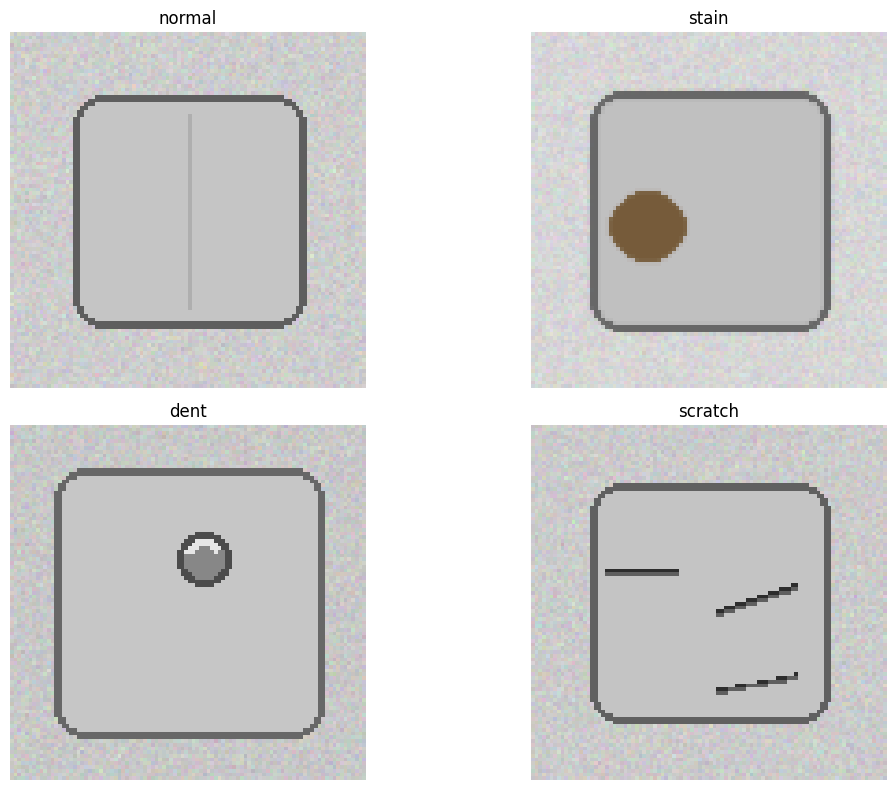

In [62]:
# Displaying sample image from each class

plt.figure(figsize=(12,8))

for i, category in enumerate(classes):

    class_path = os.path.join(image_folder, category)

    image_name = os.listdir(class_path)[0]

    image_path = os.path.join(class_path, image_name)

    # Reading image

    image = cv2.imread(image_path)

    # Converting image from BGR to RGB

    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    # Plotting image

    plt.subplot(2,2,i+1)

    plt.imshow(image)

    plt.title(category)

    plt.axis('off')

plt.tight_layout()

plt.show()

In [63]:
# Checking dimensions of sample images

for category in classes:

    class_path = os.path.join(image_folder, category)

    image_name = os.listdir(class_path)[0]

    image_path = os.path.join(class_path, image_name)

    image = cv2.imread(image_path)

    print(f"{category} image shape:", image.shape)

normal image shape: (96, 96, 3)
stain image shape: (96, 96, 3)
dent image shape: (96, 96, 3)
scratch image shape: (96, 96, 3)


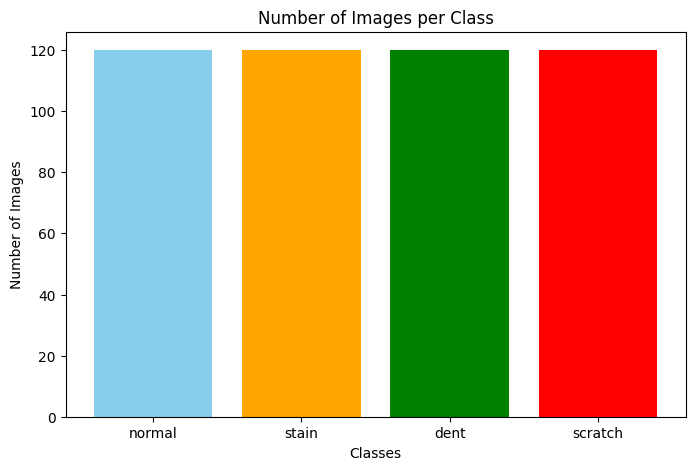

In [64]:
# Creating dataset distribution graph

class_counts = []

for category in classes:

    class_path = os.path.join(image_folder, category)

    class_counts.append(len(os.listdir(class_path)))

# Plotting bar graph

plt.figure(figsize=(8,5))

plt.bar(classes, class_counts, color=['skyblue','orange','green','red'])

plt.title("Number of Images per Class")

plt.xlabel("Classes")

plt.ylabel("Number of Images")

plt.show()

**Observation**:

The dataset contains four image classes: normal, stain, dent, and scratch. Each category contains 120 images, making the dataset balanced across all classes.

Sample images from each category were visualized to observe visual differences in surface conditions and defect patterns. The dataset includes different types of defects such as dents, stains, and scratches along with normal surface images.

Image dimensions were checked to understand image consistency before CNN preprocessing. Since all classes contain equal numbers of images, the dataset is balanced and suitable for training a CNN classification model without major class bias issues.

**Task 3: Image Preprocessing**

In [65]:
# Importing required libraries for image preprocessing

from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [66]:
# Defining image size and batch size

IMG_HEIGHT = 64

IMG_WIDTH = 64

BATCH_SIZE = 32

In [67]:
# Creating ImageDataGenerator for preprocessing and augmentation

train_datagen = ImageDataGenerator(

    rescale=1./255,              # Normalizing pixel values

    validation_split=0.2,        # Splitting dataset into training and testing sets

    rotation_range=20,           # Random image rotation

    zoom_range=0.2,              # Random zoom

    horizontal_flip=True         # Random horizontal flip
)

In [68]:
# Creating training dataset

train_data = train_datagen.flow_from_directory(

    image_folder,

    target_size=(IMG_HEIGHT, IMG_WIDTH),   # Resizing images

    batch_size=BATCH_SIZE,

    class_mode='categorical',

    subset='training'
)

Found 384 images belonging to 4 classes.


In [69]:
# Creating validation/testing dataset

test_data = train_datagen.flow_from_directory(

    image_folder,

    target_size=(IMG_HEIGHT, IMG_WIDTH),   # Resizing images

    batch_size=BATCH_SIZE,

    class_mode='categorical',

    subset='validation'
)

Found 96 images belonging to 4 classes.


In [70]:
# Displaying class labels

print(train_data.class_indices)

{'dent': 0, 'normal': 1, 'scratch': 2, 'stain': 3}


In [71]:
# Checking shape of one training batch

images, labels = next(train_data)

print("Image Batch Shape:", images.shape)

print("Label Batch Shape:", labels.shape)

Image Batch Shape: (32, 64, 64, 3)
Label Batch Shape: (32, 4)


**Observation**:

The image dataset was successfully preprocessed for CNN model training. All images were resized to 64 × 64 pixels to maintain a fixed input size and reduce computational complexity during training.

Pixel values were normalized between 0 and 1 using rescaling, which helps improve CNN learning performance and training stability.

The dataset was automatically divided into training and validation/testing sets using an 80:20 split. A total of 384 images were used for training and 96 images were used for validation/testing across 4 classes.

Image augmentation techniques such as rotation, zooming, and horizontal flipping were also applied to increase image variability and improve model generalization. The image batch shape of (32, 64, 64, 3) indicates that each batch contains 32 RGB images resized to 64 × 64 pixels, while the label batch shape of (32, 4) represents one-hot encoded labels for the 4 image classes.

**Task 4: CNN Model Creation**

In [72]:
# Importing required libraries for CNN model creation

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import Conv2D
from tensorflow.keras.layers import MaxPooling2D
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout

In [73]:
# Creating CNN Sequential model
model = Sequential()

# First Convolution Layer
model.add(Conv2D(
    32,
    (3,3),
    activation='relu',
    input_shape=(64,64,3)
))

# First Pooling Layer
model.add(MaxPooling2D(pool_size=(2,2)))

# Second Convolution Layer
model.add(Conv2D(
    64,
    (3,3),
    activation='relu'
))

# Second Pooling Layer
model.add(MaxPooling2D(pool_size=(2,2)))

# Flatten Layer
model.add(Flatten())

# Dense Layer
model.add(Dense(128, activation='relu'))

# Dropout Layer to reduce overfitting
model.add(Dropout(0.5))


# Output Layer
model.add(Dense(4, activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [74]:
# Compiling CNN model

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [75]:
# Displaying CNN model summary

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │     1,605,760 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,625,668 (6.20 MB)

 Trainable params: 1,625,668 (6.20 MB)

 Non-trainable params: 0 (0.00 B)

**Explanation**:

A CNN (Convolutional Neural Network) model was created using TensorFlow/Keras for classifying images into four categories: normal, dent, stain, and scratch. The model was designed to learn visual patterns and surface defects directly from the image dataset.

The CNN model includes convolution layers with ReLU activation functions, which help in identifying important image features such as edges, textures, scratches, and other defect patterns. Pooling layers were added after convolution layers to reduce image size and make the model more efficient during training.

The Flatten layer converts the extracted image features into a format that can be used by the dense neural network layer. A Dense layer with 128 neurons was used to learn deeper patterns from the processed images. A Dropout layer was also added to reduce overfitting and improve model generalization.

The final output layer contains 4 neurons with Softmax activation because the dataset contains four image classes. The model has a total of 1,625,668 trainable parameters, which are updated during training to improve prediction accuracy.

**Task 5: Model Training and Evaluation**

In [ ]:
# Training the CNN model

history = model.fit(

    train_data,

    validation_data=test_data,

    epochs=10
)

Epoch 1/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 5s 268ms/step - accuracy: 0.2734 - loss: 1.4618 - val_accuracy: 0.3750 - val_loss: 1.3844
Epoch 2/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 4s 359ms/step - accuracy: 0.3021 - loss: 1.3797 - val_accuracy: 0.2604 - val_loss: 1.3626
Epoch 3/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 232ms/step - accuracy: 0.3359 - loss: 1.3242 - val_accuracy: 0.5104 - val_loss: 1.2758
Epoch 4/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 232ms/step - accuracy: 0.5000 - loss: 1.1992 - val_accuracy: 0.5104 - val_loss: 1.1400
Epoch 5/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 231ms/step - accuracy: 0.5599 - loss: 1.0791 - val_accuracy: 0.5104 - val_loss: 1.0235
Epoch 6/10
 9/12 ━━━━━━━━━━━━━━━━━━━━ 0s 251ms/step - accuracy: 0.5668 - loss: 0.9661

In [ ]:
# Evaluating CNN model performance

test_loss, test_accuracy = model.evaluate(test_data)

print("Testing Loss:", test_loss)

print("Testing Accuracy:", test_accuracy)

In [ ]:
# Plotting training and validation accuracy

plt.plot(history.history['accuracy'], label='Training Accuracy')

plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title("Training and Validation Accuracy")

plt.xlabel("Epochs")

plt.ylabel("Accuracy")

plt.legend()

plt.show()

In [ ]:
# Plotting training and validation loss

plt.plot(history.history['loss'], label='Training Loss')

plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title("Training and Validation Loss")

plt.xlabel("Epochs")

plt.ylabel("Loss")

plt.legend()

plt.show()

In [ ]:
# Importing libraries for evaluation metrics

import numpy as np
# Importing seaborn library

import seaborn as sns

from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

In [ ]:
# Generating predictions on validation/testing dataset

predictions = model.predict(test_data)

# Converting probabilities into class labels

predicted_classes = np.argmax(predictions, axis=1)

# Actual class labels

true_classes = test_data.classes

In [ ]:
# Creating confusion matrix

cm = confusion_matrix(true_classes, predicted_classes)

# Plotting confusion matrix

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=classes,
    yticklabels=classes
)

plt.title("Confusion Matrix")

plt.xlabel("Predicted Class")

plt.ylabel("Actual Class")

plt.show()

In [ ]:
# Displaying classification report

print(classification_report(true_classes, predicted_classes))

In [ ]:
# Displaying sample predictions from test dataset

images, labels = next(test_data)

preds = model.predict(images)

predicted_labels = np.argmax(preds, axis=1)

true_labels = np.argmax(labels, axis=1)

plt.figure(figsize=(12,10))

for i in range(8):

    plt.subplot(2,4,i+1)

    plt.imshow(images[i])

    plt.title(f"Pred: {classes[predicted_labels[i]]}\nActual: {classes[true_labels[i]]}")

    plt.axis('off')

plt.tight_layout()

plt.show()

**Observation**:

The CNN model was successfully trained on the image dataset for 10 epochs. During training, both training accuracy and validation accuracy gradually improved, while training and validation loss decreased continuously. This shows that the model was able to learn important visual patterns from the images over time.

The final testing accuracy achieved by the model was around 84%, which indicates that the CNN was able to classify many images correctly. The accuracy and loss graphs also show stable learning behavior without major fluctuations during training.

The confusion matrix helped analyze how the model predicted each image class such as normal, dent, stain, and scratch. Some classes were predicted correctly, while some images were misclassified because certain defect patterns looked visually similar to each other.

The classification report showed lower precision and recall values for some classes, which means the model still faced difficulty distinguishing between similar surface defects. Even though the overall testing accuracy was good, the detailed metrics suggest that the model can still be improved further with more training data, more epochs, or a deeper CNN architecture.

Sample prediction outputs also showed that the model was able to correctly identify several test images by learning defect-related visual features such as stains, scratches, and dents from the dataset.

**Task 7: Business Use Case Mapping**

Business Use Case Mapping

This type of computer vision solution can be highly useful in the manufacturing industry for automated quality inspection and defect detection. In many manufacturing companies, products need to be checked for surface defects such as scratches, dents, stains, cracks, or damaged areas before they are delivered to customers.

Traditionally, this inspection process is done manually by workers, which can be time-consuming, expensive, and sometimes inaccurate due to human error. A CNN-based image classification system can automate this process by analyzing product images and identifying defective items in real time.

In this project, the CNN model was trained to classify images into categories like normal, dent, stain, and scratch. A similar approach can be used in industries such as automobile manufacturing, mobile phone production, metal sheet inspection.

For example, in a smartphone manufacturing company, cameras installed on the production line can capture images of products and the CNN model can automatically detect scratches or dents on the device surface. This helps improve product quality, reduce manual inspection effort, minimize defective product delivery, and increase operational efficiency.

Computer vision solutions like this are becoming increasingly important in Industry 4.0 and smart manufacturing environments where automation and AI-based quality control play a major role.